## Setup : Importing Necessary Librraries

In [83]:
from liquipediapy import liquipediapy
from io import StringIO
import pandas as pd
from datetime import datetime
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Milestone 1 : Data Collection and Problem Definitons

In [84]:
# grab the table from https://liquipedia.net/rainbowsix/Portal:Statistics/Player_earnings and store it in a DataFrame
client = liquipediapy('my_r6_stats_app', 'rainbowsix')
soup, redirect = client.parse('Portal:Statistics/Player_earnings')
html_buf = StringIO(str(soup))
df = pd.read_html(html_buf)[0]

# output to check table pulled sucessfully
print(f"{df.head()}")

   #   Player  Achievements  Unnamed: 3  Unnamed: 4  Unnamed: 5  Earnings
0  1  Shaiiko           NaN          20          14           6  $882,912
1  2     BriD           NaN          16          18           3  $750,959
2  3    Cyber           NaN          10           2          10  $593,322
3  4   HerdsZ           NaN           5           9           8  $557,192
4  5   Kheyze           NaN           6          10           8  $557,089


In [85]:
# grab the table from https://liquipedia.net/rainbowsix/Birthday_list and store it in a DataFrame
client = liquipediapy('my_r6_stats_app', 'rainbowsix')
soup, redirect = client.parse('Birthday_list')
html_buf = StringIO(str(soup))
bdf = pd.read_html(html_buf)[0]

# output to check table pulled sucessfully
print(f"{bdf.head()}")

   Birth year     Month/Day       ID             Name
0        1977      March 25      DnA     David Thomas
1        1977     August 05  Tomozoh  Tomohisa Yamano
2        1980  September 16      qeP     Ricardo Fugi
3        1981      March 15     DraZ      Razig Abida
4        1981   November 18   GaelV8       Gaël Trico


In [86]:
# compute age in years (integer) and store in new column
bdf['birthday'] = pd.to_datetime(
    bdf['Birth year'].astype(str) + ' ' + bdf['Month/Day'],
    format='%Y %B %d'
)
today = pd.Timestamp.now().normalize()
bdf['age'] = ((today - bdf['birthday']).dt.days / 365.25).astype(int)

# merge the new info into the old DataFrame
birthdays = bdf[['age','Name','ID']]
df = (
    df.merge(birthdays, how='left', left_on='Player', right_on='ID')
    .drop(columns='ID')
)

# reorder the columns
front = ['#', 'age','Name','Player']
rest  = [c for c in df.columns if c not in front]
df = df[front + rest]

# output to verify merge
print(f"{df.head()}")

   #   age             Name   Player  Achievements  Unnamed: 3  Unnamed: 4  \
0  1  26.0  Stéphane Lebleu  Shaiiko           NaN          20          14   
1  2  28.0   Loïc Chongthep     BriD           NaN          16          18   
2  3  26.0      Jaime Ramos    Cyber           NaN          10           2   
3  4  24.0  Gustavo Herdina   HerdsZ           NaN           5           9   
4  5  22.0    Diego Zanello   Kheyze           NaN           6          10   

   Unnamed: 5  Earnings  
0           6  $882,912  
1           3  $750,959  
2          10  $593,322  
3           8  $557,192  
4           8  $557,089  


In [87]:
# export raw DataFrame to a .csv file
output_path = 'raw_player_earnings.csv'
df.to_csv(output_path, index=False)

## Milestone 2 : Pre-Processing & Exploratory Data Analysis

In [88]:
# show column types and non-null counts
df.info()

# show basic numeric summaries
df.describe()

# count of duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #             1669 non-null   int64  
 1   age           990 non-null    float64
 2   Name          979 non-null    object 
 3   Player        1669 non-null   object 
 4   Achievements  0 non-null      float64
 5   Unnamed: 3    1669 non-null   int64  
 6   Unnamed: 4    1669 non-null   int64  
 7   Unnamed: 5    1669 non-null   int64  
 8   Earnings      1669 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 117.5+ KB
Duplicate rows: 0


In [89]:
# drop the Achievements column as it's all NaN values and not needed anyways
df.drop(columns=['Achievements'], inplace=True)

# fill NaN values and fix value types
df['Earnings'] = (
    df['Earnings']
        .str.replace(r'[\$,]', '', regex=True)  # drop $ and commas
        .astype(int)                            # cast to integer
)
df['Name'].fillna("Unknown")
df['age'] = (
    df['age']
        .fillna(df['age'].mean())   # actually call fillna, returning a Series
        .round()                    # optional: round 24.6 → 25
        .astype(int)                # now safe to cast to int
)

# rename remaining columns
df = df.rename(columns={
    '#':             'rank',
    'Name':          'player_name',
    'Player':        'gamertag',
    'Unnamed: 3':    'num_frst',
    'Unnamed: 4':    'num_scnd',
    'Unnamed: 5':    'num_thrd',
    'Earnings':      'earnings'
})

# output to ensure fixes were correctly made
print(f"{df.head()}")

   rank  age      player_name gamertag  num_frst  num_scnd  num_thrd  earnings
0     1   26  Stéphane Lebleu  Shaiiko        20        14         6    882912
1     2   28   Loïc Chongthep     BriD        16        18         3    750959
2     3   26      Jaime Ramos    Cyber        10         2        10    593322
3     4   24  Gustavo Herdina   HerdsZ         5         9         8    557192
4     5   22    Diego Zanello   Kheyze         6        10         8    557089


In [90]:
# sum and insert new column of total podium placements
df.insert(
    loc=7,
    column='num_top3',
    value=df[['num_frst','num_scnd','num_thrd']].sum(axis=1)
)

# calc ratios of earnings per podium placement
ratios = df['earnings'] / df['num_top3']

# turn any inf into NaN, then fill NaNs with 0
ratios = (
    ratios
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
)

# insert new column of earnings per podium placement
df.insert(
    loc=9,
    column='earnings_per_top3',
    value=ratios.round().astype(int)
)

# output to ensure columns added
print(f"{df.head()}")

   rank  age      player_name gamertag  num_frst  num_scnd  num_thrd  \
0     1   26  Stéphane Lebleu  Shaiiko        20        14         6   
1     2   28   Loïc Chongthep     BriD        16        18         3   
2     3   26      Jaime Ramos    Cyber        10         2        10   
3     4   24  Gustavo Herdina   HerdsZ         5         9         8   
4     5   22    Diego Zanello   Kheyze         6        10         8   

   num_top3  earnings  earnings_per_top3  
0        40    882912              22073  
1        37    750959              20296  
2        22    593322              26969  
3        22    557192              25327  
4        24    557089              23212  


Kept 1420 of 1669 rows after outlier removal


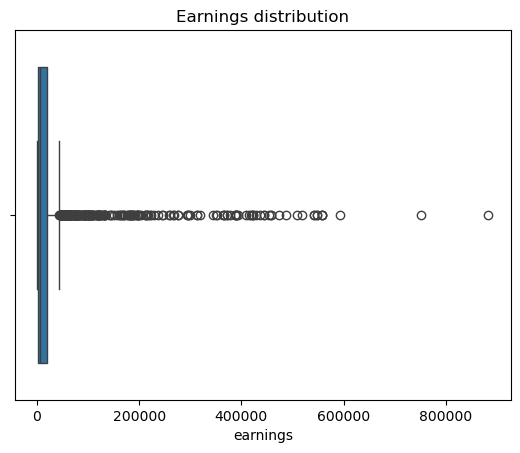

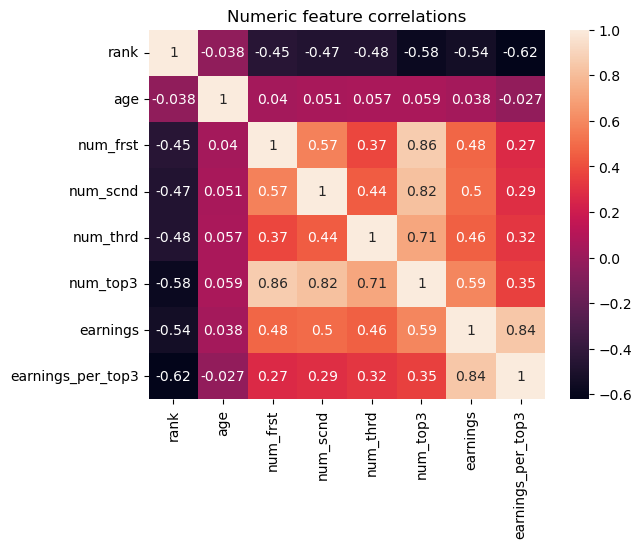

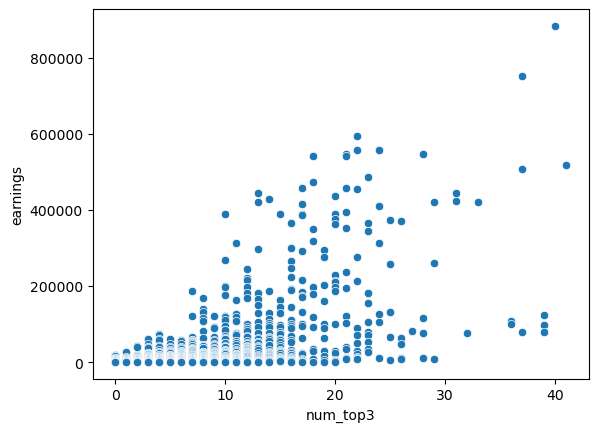

In [91]:
# IQR-based filtering
Q1, Q3 = df['earnings'].quantile([.25, .75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df_clipped = df[(df['earnings'] >= lower) & (df['earnings'] <= upper)]
print(f"Kept {len(df_clipped)} of {len(df)} rows after outlier removal")

# boxplot of the earnings
sns.boxplot(x=df['earnings'])
plt.title("Earnings distribution")
plt.show()

# correlation matrix & heatmap
corr = df.select_dtypes(int).corr()
sns.heatmap(corr, annot=True)
plt.title("Numeric feature correlations")
plt.show()

# scatter earnings vs. num_top3
sns.scatterplot(x='num_top3', y='earnings', data=df)
plt.show()

In [92]:
# heavily skewed to the right, so create a new feature of log earnings to help tame it 
df['log_earnings']=np.log1p(df['earnings'])
# also create a feature that flags outliers
df['is_outlier'] = ~df['earnings'].between(lower, upper)

print(f"{df.head()}")

   rank  age      player_name gamertag  num_frst  num_scnd  num_thrd  \
0     1   26  Stéphane Lebleu  Shaiiko        20        14         6   
1     2   28   Loïc Chongthep     BriD        16        18         3   
2     3   26      Jaime Ramos    Cyber        10         2        10   
3     4   24  Gustavo Herdina   HerdsZ         5         9         8   
4     5   22    Diego Zanello   Kheyze         6        10         8   

   num_top3  earnings  earnings_per_top3  log_earnings  is_outlier  
0        40    882912              22073     13.690982        True  
1        37    750959              20296     13.529108        True  
2        22    593322              26969     13.293494        True  
3        22    557192              25327     13.230667        True  
4        24    557089              23212     13.230482        True  


Intercept: 7.7950
Slope:     0.1571
R² score:  0.4256


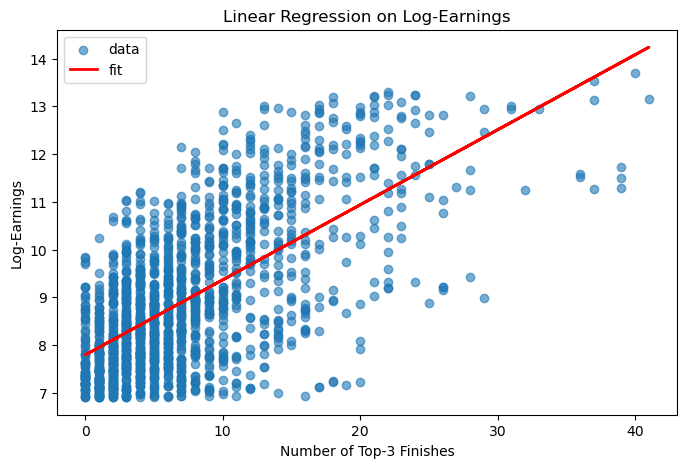

In [93]:
# create a linear regression of the full DataFrame, but using the log earnings
X = df['num_top3'].values.reshape(-1, 1)
y = df['log_earnings']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# output metrics
print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope:     {model.coef_[0]:.4f}")
print(f"R² score:  {r2_score(y, y_pred):.4f}")

# plot scatters and regression lines to compare results
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6, label='data')
plt.plot(X, y_pred, color='red', linewidth=2, label='fit')
plt.xlabel("Number of Top-3 Finishes")
plt.ylabel("Log-Earnings")
plt.title("Linear Regression on Log-Earnings")
plt.legend()
plt.show()

In [94]:
# done cleaning and pre-processing, so export DataFrame to a .csv file
output_path = 'processed_player_earnings.csv'
df.to_csv(output_path, index=False)

## Milestone 3 : Modeling and Implementation

Intercept: 10.9886
Slope:     0.0475
R² score:  0.2233


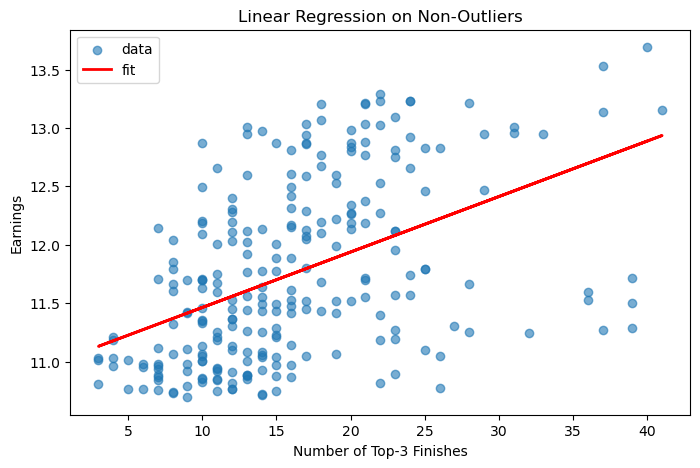

In [95]:
# create another linear regression, but this time with the clipped dataframe
df_no_out = df[df['is_outlier']].copy()

X_no = df_no_out['num_top3'].values.reshape(-1, 1)
y_no = df_no_out['log_earnings']

model_no = LinearRegression().fit(X_no, y_no)
y_no_pred = model_no.predict(X_no)

# output the same metrics to compare to those of the log-earnings linear regression
print(f"Intercept: {model_no.intercept_:.4f}")
print(f"Slope:     {model_no.coef_[0]:.4f}")
print(f"R² score:  {r2_score(y_no, y_no_pred):.4f}")

# also plot this linear regression once again to comapre to the log-earnings one
plt.figure(figsize=(8,5))
plt.scatter(X_no, y_no, alpha=0.6, label='data')
plt.plot(X_no, y_no_pred, color='red', linewidth=2, label='fit')
plt.xlabel("Number of Top-3 Finishes")
plt.ylabel("Earnings")
plt.title("Linear Regression on Non-Outliers")
plt.legend()
plt.show()

Intercept: 7.8030
Slope (num_top3): 0.1572
Slope (age):      -0.0003
R² score:        0.4256


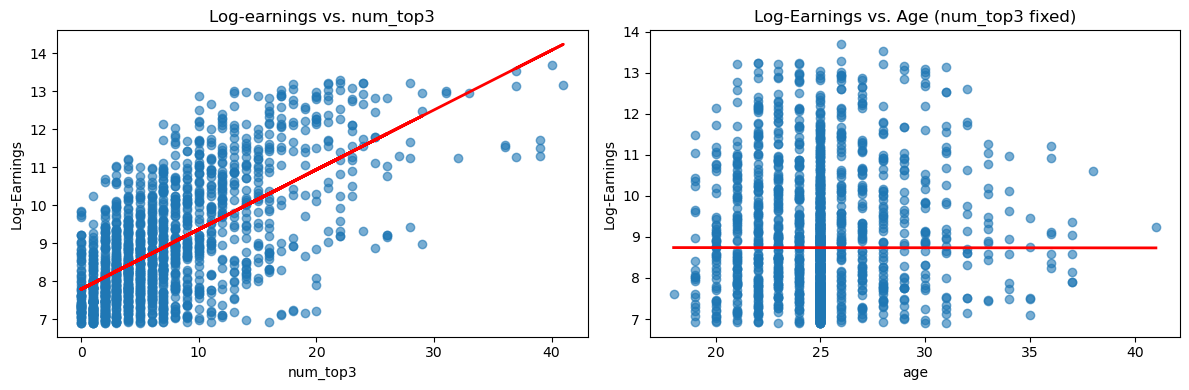

In [96]:

# create a two-feature linear regression (num_top3 and age) to show that age has little-to-no predictive power
X = df[['num_top3','age']]
y = df['log_earnings']

# avoid a feature-name mismatch warning by converting to plain NumPy arrays for both .fit() and .predict()
model = LinearRegression().fit(X.values, y.values)
y_pred = model.predict(X.values)

# output the same metrics to compare to those of the log-earnings linear regression
print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope (num_top3): {model.coef_[0]:.4f}")
print(f"Slope (age):      {model.coef_[1]:.4f}")
print(f"R² score:        {r2_score(y, y_pred):.4f}")

# scatter / partial‐regression plots
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].scatter(df['num_top3'],    y, alpha=0.6)
axes[0].plot(df['num_top3'], y_pred, color='r', lw=2)
axes[0].set_title("Log-earnings vs. num_top3")
axes[1].scatter(df['age'],         y, alpha=0.6)

# show the age effect holding num_top3 constant:
# compute predictions at median podium count
median_top3 = df['num_top3'].median()
age_grid    = np.linspace(df['age'].min(), df['age'].max(), 50)
X_line      = np.column_stack([np.repeat(median_top3,50), age_grid])
y_line      = model.predict(X_line)
axes[1].plot(age_grid, y_line, color='r', lw=2)
axes[1].set_title("Log-Earnings vs. Age (num_top3 fixed)")

for ax in axes:
    ax.set_xlabel(ax is axes[0] and 'num_top3' or 'age')
    ax.set_ylabel('Log-Earnings')
plt.tight_layout()
plt.show()
